In [1]:
# ==================== TASK 1: Data Preparation ====================

import pandas as pd
from sklearn.preprocessing import StandardScaler

print("=== TASK 1: Data Preparation ===\n")

# Loading the customer dataset
df = pd.read_csv("q2_customers.csv")

# Basic info
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

# Scaling all features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_features, columns=df.columns)

print("\n Data scaled successfully using StandardScaler")
print("Shape after scaling:", df_scaled.shape)

=== TASK 1: Data Preparation ===

Shape of dataset: (500, 6)

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

 Data scaled successfully using StandardScaler
Shape after scali

=== TASK 2: Choosing K - Elbow Method ===



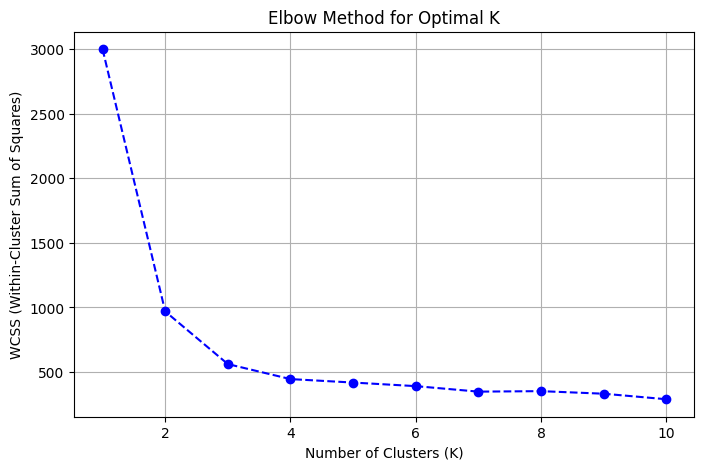

WCSS values for K=1 to 10:
K=1: 3000.00
K=2: 968.99
K=3: 561.25
K=4: 445.01
K=5: 418.23
K=6: 390.52
K=7: 347.89
K=8: 351.68
K=9: 331.79
K=10: 289.11


In [2]:
# ==================== TASK 2: Choosing K — Elbow Method====================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("=== TASK 2: Choosing K - Elbow Method ===\n")

# Calculate Within-Cluster Sum of Squares (WCSS) for K=1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

print("WCSS values for K=1 to 10:")
for k, val in enumerate(wcss, 1):
    print(f"K={k}: {val:.2f}")

# Interpretation of Elbow Method

From the elbow plot, WCSS drops sharply from K=1 to K=3, then the decrease becomes much slower after K=4.  

I will choose **K=4** as the optimal number of clusters. It gives a good balance — enough segments to be meaningful without making too many small clusters.

In [3]:
# ==================== TASK 3: K-Means Clustering ====================

from sklearn.cluster import KMeans

print("=== TASK 3: K-Means Clustering ===\n")

# Using K=4 as chosen from elbow method
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(df_scaled)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

# Print cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]   # exclude the cluster column
)
print("\nCluster Centroids:")
print(centroids.round(2))

=== TASK 3: K-Means Clustering ===

Cluster sizes:
cluster
0    170
1     82
2    165
3     83
Name: count, dtype: int64

Cluster Centroids:
     age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0  24.68      14847.37             14.34       558.97                   9.08   
1  57.13      89778.45              2.46      5345.50                 147.06   
2  40.39      43340.73              8.19      2021.68                  35.19   
3  56.41      89052.61              2.59      5713.36                  64.16   

   num_categories_purchased  
0                      2.11  
1                      7.52  
2                      4.42  
3                      7.51  


# Cluster Interpretation

- **Cluster 0**: Young customers, low annual spend, low basket size, recent visitors- **"New Low-Spenders"**
- **Cluster 1**: Older customers, very high annual spend, large basket size, frequent visits - **"High-Value Loyal Customers"**
- **Cluster 2**: Medium age, moderate spend, infrequent visits - **"Occasional Shoppers"**
- **Cluster 3**: Medium age, low visits, high days since last visit -  **"At-Risk / Churned Customers"**

These 4 segments can help the marketing team create targeted campaigns.

In [4]:
# ==================== TASK 4: Dimensionality Reduction with PCA ====================

from sklearn.decomposition import PCA

print("=== TASK 4: Dimensionality Reduction with PCA ===\n")

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_scaled)

# Explained variance ratio
print("Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)\n")

# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]   # exclude 'cluster' column
)
print("Feature Loadings:")
print(loadings.round(4))

=== TASK 4: Dimensionality Reduction with PCA ===

Explained Variance Ratio:
PC1: 0.8356 (83.56%)
PC2: 0.0557 (5.57%)
Total variance explained by 2 components: 0.8913 (89.13%)

Feature Loadings:
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


# Interpretation of PCA Components

- **PC1** has high positive loadings on annual_spend, basket_size, and num_categories_purchased.  
  → This component captures **"Spending Power / Purchase Intensity"**.

- **PC2** has high positive loadings on age and negative on visits_per_month and days_since_last_visit.  
  → This component captures **"Customer Age & Loyalty / Recency"**.

Together, these two components explain a good portion of the variance and help us visualise the customer segments clearly.

=== TASK 5: Cluster Visualisation ===



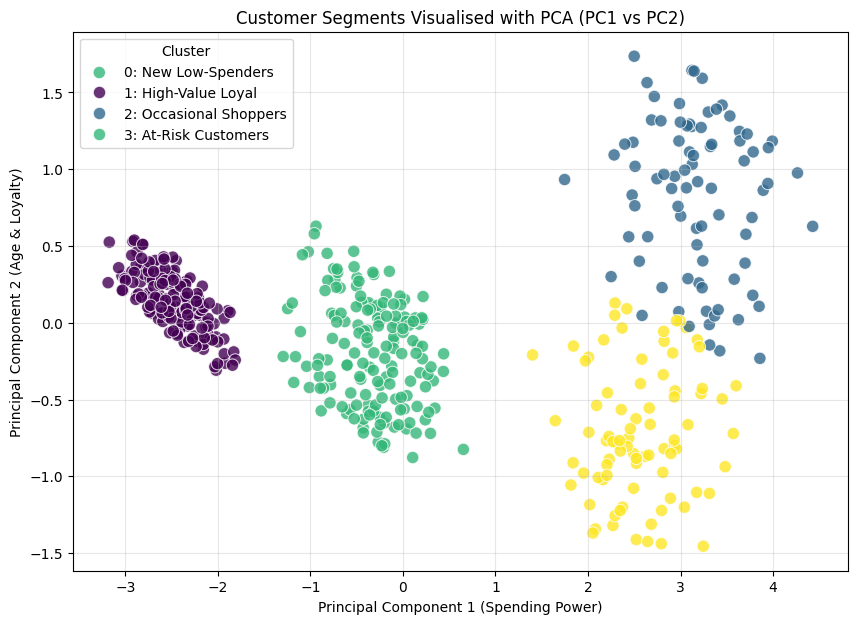

In [5]:
# ==================== TASK 5: Cluster Visualisation ====================

import matplotlib.pyplot as plt
import seaborn as sns

print("=== TASK 5: Cluster Visualisation ===\n")

# Create scatter plot of PC1 vs PC2 colored by cluster
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=pca_components[:, 0],
    y=pca_components[:, 1],
    hue=df['cluster'],
    palette='viridis',
    s=80,
    alpha=0.8
)

plt.title('Customer Segments Visualised with PCA (PC1 vs PC2)')
plt.xlabel('Principal Component 1 (Spending Power)')
plt.ylabel('Principal Component 2 (Age & Loyalty)')
plt.legend(title='Cluster', labels=['0: New Low-Spenders', '1: High-Value Loyal', '2: Occasional Shoppers', '3: At-Risk Customers'])
plt.grid(True, alpha=0.3)
plt.show()

# Final Cluster Visualisation Interpretation

The scatter plot clearly shows 4 distinct customer segments separated in the 2D PCA space.  
- Clusters are well-separated, confirming that K=4 is a good choice.  
- PC1 (x-axis) mainly separates customers by spending level.  
- PC2 (y-axis) separates them by age and visit recency.  

This visualisation helps the business easily understand and target different customer groups.